# **Task 3: Mini Exploratory Data Analysis (EDA) on Titanic Dataset**

# Step 1: Import Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the Titanic Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 3: Handle Missing Values in the Age Column

In [3]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

/tmp/ipykernel_5620/1809399462.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


# Check:

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Step 4: Remove Cabin Column

In [5]:
df.drop(columns=["Cabin"], inplace=True)

# Step 5: Create Age Group Categories

In [6]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

# Check:

In [7]:
df[["Age","AgeGroup"]].head()

,Age,AgeGroup
0,22.0,YoungAdult
1,38.0,Adult
2,26.0,YoungAdult
3,35.0,Adult
4,35.0,Adult


# Step 6: Question 1. Survival Rate by Age Group



*   The survival rate varied among different age groups, with some age groups having a higher chance of survival than others.




In [8]:
age_survival = df.groupby("AgeGroup")["Survived"].mean()
print(age_survival)

AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.331096
Adult         0.423237
Senior        0.343750
Name: Survived, dtype: float64


/tmp/ipykernel_5620/3256121588.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


# Visualization:

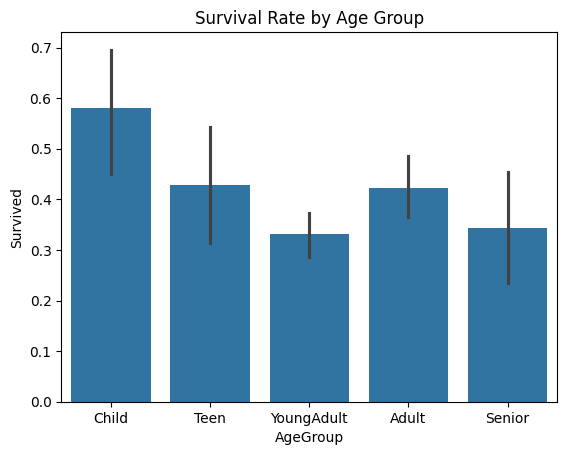

In [9]:
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival Rate by Age Group")
plt.show()

# Step 7: Question 2. Survival Rate by Embarkation Port



*  Passengers embarking from different ports showed different survival rates.


In [10]:
port_survival = df.groupby("Embarked")["Survived"].mean()
print(port_survival)

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


# Visualization:

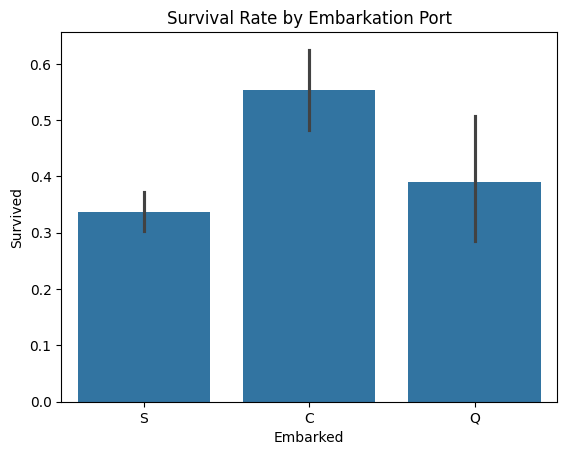

In [11]:
sns.barplot(x="Embarked", y="Survived", data=df)
plt.title("Survival Rate by Embarkation Port")
plt.show()

# Step 8:  Question 3.Survival Rate by Family Size (SibSp + Parch):

*  Family size influenced survival, as passengers traveling with small families generally had higher survival rates than those traveling alone or in very large families.   



In [12]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Check:

In [13]:
df[["SibSp","Parch","FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


# Step 9: Survival Rate by Family Size

In [14]:
family_survival = df.groupby("FamilySize")["Survived"].mean()
print(family_survival)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


# Visualization:

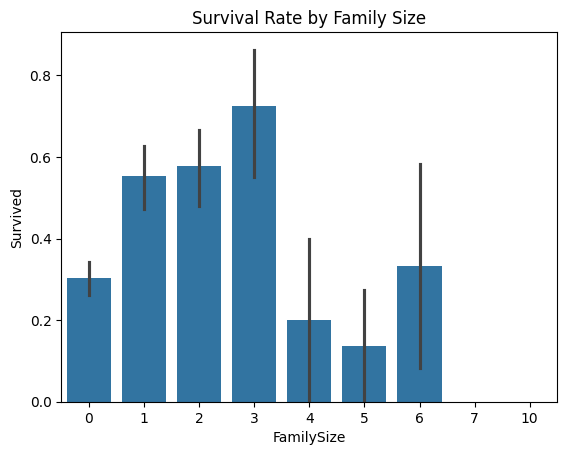

In [15]:
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.title("Survival Rate by Family Size")
plt.show()

# Step 10: Age Distribution Histogram

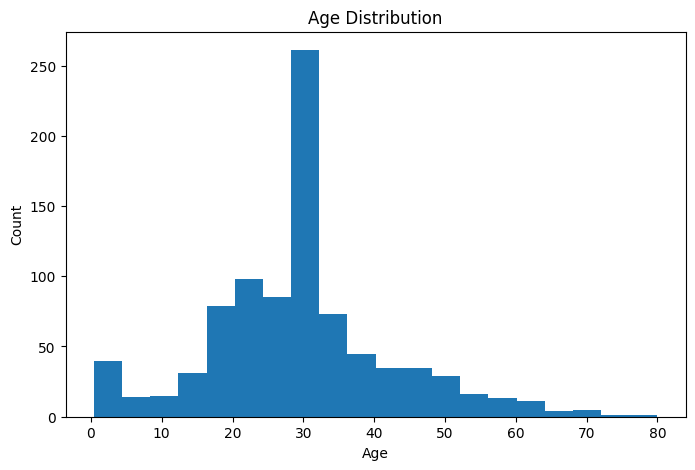

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Step 11: Correlation Heatmap

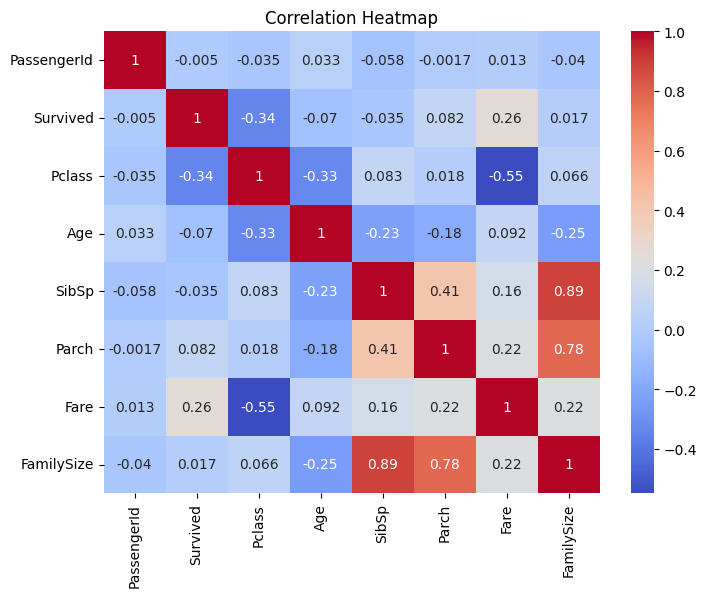

In [17]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Conclusions:


1. The survival rate varied across different age groups.

2. Passengers from different embarkation ports had different chances of survival.

3. Family size influenced survival probability.

4. Most passengers were young adults based on the age distribution.

5. The correlation heatmap helped identify relationships between numerical features.


